In [9]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from scipy.linalg import hadamard
from scipy.fftpack import dct
import time
import warnings

# 忽略计算过程中的警告（如除以零，会在代码中处理）
warnings.filterwarnings("ignore")

# ==========================================
# 1. 数据预处理 (NaN 修复专家)
# ==========================================
def preprocess_data(X_raw):
    """
    数据清洗流程：
    1. 线性插值：修复中间缺失的连续段
    2. 均值填充：修复边缘缺失（无法插值的部分）
    3. 兜底填充：如果整行都是NaN，填0
    """
    # 转为 DataFrame 处理更方便
    df = pd.DataFrame(X_raw)
    
    # 1. 线性插值 (沿时间轴 axis=1)
    # limit_direction='both' 保证开头结尾也能尝试插值
    df = df.interpolate(method='linear', axis=1, limit_direction='both')
    
    # 2. 行均值填充 (处理插值搞不定的边缘 NaN)
    # 计算每行的均值 (忽略NaN)
    row_means = df.mean(axis=1)
    # 用该行的均值填充该行的 NaN
    # apply 逐行操作，速度稍慢但逻辑最准确
    df = df.apply(lambda row: row.fillna(row_means[row.name]), axis=1)
    
    # 3. 兜底 (如果某一行全是NaN，均值也是NaN，最后填0)
    df = df.fillna(0.0)
    
    return df.values.astype(np.float32)

# ==========================================
# 2. 核心转换类 (6种核)
# ==========================================
class KernelComparisonTransform:
    def __init__(self, kernel_len=16, num_kernels=16):
        self.kernel_len = kernel_len
        self.num_kernels = num_kernels

    def generate_kernels(self, method):
        # --- 组1: 随机类 ---
        if method == 'Gaussian Random':
            return torch.randn(self.num_kernels, 1, self.kernel_len)
        elif method == 'MiniROCKET':
            kernels = np.random.choice([-1, 2], size=(self.num_kernels, 1, self.kernel_len))
            return torch.FloatTensor(kernels)
        elif method == 'Bernoulli (Sparse)':
            kernels = np.random.choice([-1, 0, 1], size=(self.num_kernels, 1, self.kernel_len))
            return torch.FloatTensor(kernels)
        # --- 组2: 正交类 ---
        elif method == 'QR-Orthogonal':
            rand_mat = torch.randn(self.num_kernels, self.kernel_len)
            q, r = torch.linalg.qr(rand_mat)
            return q.unsqueeze(1)
        elif method == 'DCT':
            eye = np.eye(self.kernel_len)
            dct_basis = dct(eye, axis=1, norm='ortho')
            return torch.FloatTensor(dct_basis[:self.num_kernels]).unsqueeze(1)
        elif method == 'Hadamard':
            h_mat = hadamard(self.kernel_len)
            return torch.FloatTensor(h_mat[:self.num_kernels]).unsqueeze(1)
        else:
            raise ValueError(f"Unknown method: {method}")

    def transform(self, X, method):
        # 计时 (纯计算时间)
        t_start = time.perf_counter()
        
        X_tensor = torch.FloatTensor(X).unsqueeze(1)
        if torch.cuda.is_available(): X_tensor = X_tensor.cuda()
            
        weight = self.generate_kernels(method)
        if torch.cuda.is_available(): weight = weight.cuda()
            
        # 卷积
        conv_out = F.conv1d(X_tensor, weight, padding=0)
        # PPV 特征
        ppv = torch.mean((conv_out > 0).float(), dim=2)
        
        if torch.cuda.is_available(): torch.cuda.synchronize()
        t_end = time.perf_counter()
        
        features = ppv.cpu().numpy()
        return features, (t_end - t_start) * 1000 # 转毫秒

# ==========================================
# 3. MAPC 计算 (无图版)
# ==========================================
def calculate_mapc_value(features):
    """
    只返回 MAPC 数值，不需要矩阵
    """
    # 1. 剔除无效特征 (标准差接近0的常数列)
    std = np.std(features, axis=0)
    valid_mask = std > 1e-9
    
    # 如果有效特征少于2个，无法计算相关性
    if np.sum(valid_mask) < 2:
        return 0.0
        
    feat_valid = features[:, valid_mask]
    
    # 2. 计算相关系数矩阵
    corr_matrix = np.corrcoef(feat_valid, rowvar=False)
    
    # 3. 处理计算可能产生的 NaN (例如极小数值误差)
    if np.isnan(corr_matrix).all():
        return 0.0
    corr_matrix = np.nan_to_num(corr_matrix, nan=0.0)
    
    # 4. 计算 MAPC (绝对值 -> 去对角线 -> 求均值)
    abs_corr = np.abs(corr_matrix)
    np.fill_diagonal(abs_corr, 0)
    
    n = abs_corr.shape[0]
    mapc = np.sum(abs_corr) / (n * (n - 1))
    
    return mapc

# ==========================================
# 4. 主程序
# ==========================================
def main():
    # --- 配置路径 ---
    base_folder = r'F:\datasheet\03时间序列分类\02urc\UCRArchive_2018' 
    output_dir = "./03_final_stats_csv_only"
    # ---------------

    os.makedirs(output_dir, exist_ok=True)
    
    methods = [
        'Gaussian Random', 'MiniROCKET', 'Bernoulli (Sparse)', 
        'QR-Orthogonal',   'DCT',        'Hadamard'
    ]
    
    try:
        # 获取所有子文件夹并排序
        subfolders = sorted([f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))])
    except FileNotFoundError:
        print(f"❌ 错误：找不到路径 {base_folder}")
        return

    print(f"🚀 开始全量计算 (NaN修复 + MAPC统计)")
    print(f"📂 数据集数量: {len(subfolders)}")
    print(f"💾 结果将保存至: {output_dir}")
    print("-" * 60)

    results_list = []
    transformer = KernelComparisonTransform(kernel_len=16, num_kernels=16)

    start_global = time.time()

    for idx, subfolder in enumerate(subfolders):
        train_file = os.path.join(base_folder, subfolder, f"{subfolder}_TRAIN.tsv")
        
        # 打印进度 (覆盖同一行)
        print(f"\r[{idx+1}/{len(subfolders)}] Processing: {subfolder:<30}", end="")
        
        if not os.path.exists(train_file): continue
            
        try:
            # 1. 读取原始数据
            df_raw = pd.read_csv(train_file, sep="\t", header=None)
            X_raw = df_raw.iloc[:, 1:].values
            
            # 2. 【关键】数据清洗 (Mean/Interpolate)
            X = preprocess_data(X_raw)
            num_samples = len(X)
            
            # 极少情况：清洗后样本太少或长度不够，跳过
            if num_samples < 2 or X.shape[1] < 16:
                continue

            # 3. 计算 6 种核
            row_data = {'Dataset': subfolder, 'Samples': num_samples}
            
            for method in methods:
                # 提取特征 + 计时
                features, total_time_ms = transformer.transform(X, method)
                
                # 计算 MAPC
                mapc = calculate_mapc_value(features)
                
                # 记录
                row_data[f"{method} MAPC"] = mapc
                row_data[f"{method} Time(ms)"] = total_time_ms / num_samples
            
            results_list.append(row_data)

        except Exception as e:
            # 遇到坏文件不中断，只记录错误
            print(f"\n❌ Error in {subfolder}: {e}")

    total_time_global = time.time() - start_global
    print(f"\n\n✅ 全部完成！总耗时: {total_time_global:.2f} 秒")
    
    # --- 保存 CSV ---
    df_results = pd.DataFrame(results_list)
    csv_path = os.path.join(output_dir, "Full_UCR_Kernel_Stats_6Methods.csv")
    df_results.to_csv(csv_path, index=False)
    
    # --- 打印最终汇总表 (直接用于论文) ---
    mean_stats = df_results.mean(numeric_only=True)
    
    print("\n📋 === 最终统计结果 (Final Aggregated Stats) ===")
    print(f"{'Kernel Type':<20} | {'MAPC (Independence)':<20} | {'Time (ms/sample)':<20}")
    print("-" * 70)
    
    for method in methods:
        mapc_val = mean_stats[f"{method} MAPC"]
        time_val = mean_stats[f"{method} Time(ms)"]
        print(f"{method:<20} | {mapc_val:.5f}                | {time_val:.5f}")
    
    print("-" * 70)
    print(f"详细数据已保存: {csv_path}")

if __name__ == "__main__":
    main()

🚀 开始全量计算 (NaN修复 + MAPC统计)
📂 数据集数量: 129
💾 结果将保存至: ./03_final_stats_csv_only
------------------------------------------------------------
[129/129] Processing: Yoga                          th_datasets_adjusted

✅ 全部完成！总耗时: 8.81 秒

📋 === 最终统计结果 (Final Aggregated Stats) ===
Kernel Type          | MAPC (Independence)  | Time (ms/sample)    
----------------------------------------------------------------------
Gaussian Random      | 0.68545                | 0.00930
MiniROCKET           | 0.75226                | 0.00794
Bernoulli (Sparse)   | 0.63682                | 0.00773
QR-Orthogonal        | 0.68734                | 0.00812
DCT                  | 0.63315                | 0.00800
Hadamard             | 0.36195                | 0.00817
----------------------------------------------------------------------
详细数据已保存: ./03_final_stats_csv_only\Full_UCR_Kernel_Stats_6Methods.csv


🚀 开始调试模式，尝试读取前 10 个数据集...
✅ 成功加载 [1]: ACSF1 (Shape: (100, 1460))
✅ 成功加载 [2]: Adiac (Shape: (390, 176))
✅ 成功加载 [3]: AllGestureWiimoteX (Shape: (300, 500))
✅ 成功加载 [4]: AllGestureWiimoteY (Shape: (300, 500))
✅ 成功加载 [5]: AllGestureWiimoteZ (Shape: (300, 500))
✅ 成功加载 [6]: ArrowHead (Shape: (36, 251))
✅ 成功加载 [7]: BME (Shape: (30, 128))
✅ 成功加载 [8]: Beef (Shape: (30, 470))
✅ 成功加载 [9]: BeetleFly (Shape: (20, 512))
✅ 成功加载 [10]: BirdChicken (Shape: (20, 512))

🎨 成功处理了 10 个数据集，开始绘图...
✅ 修复完成！图片已保存至: ./05_journal_plots_debug/Journal_Heatmap_Debug.png


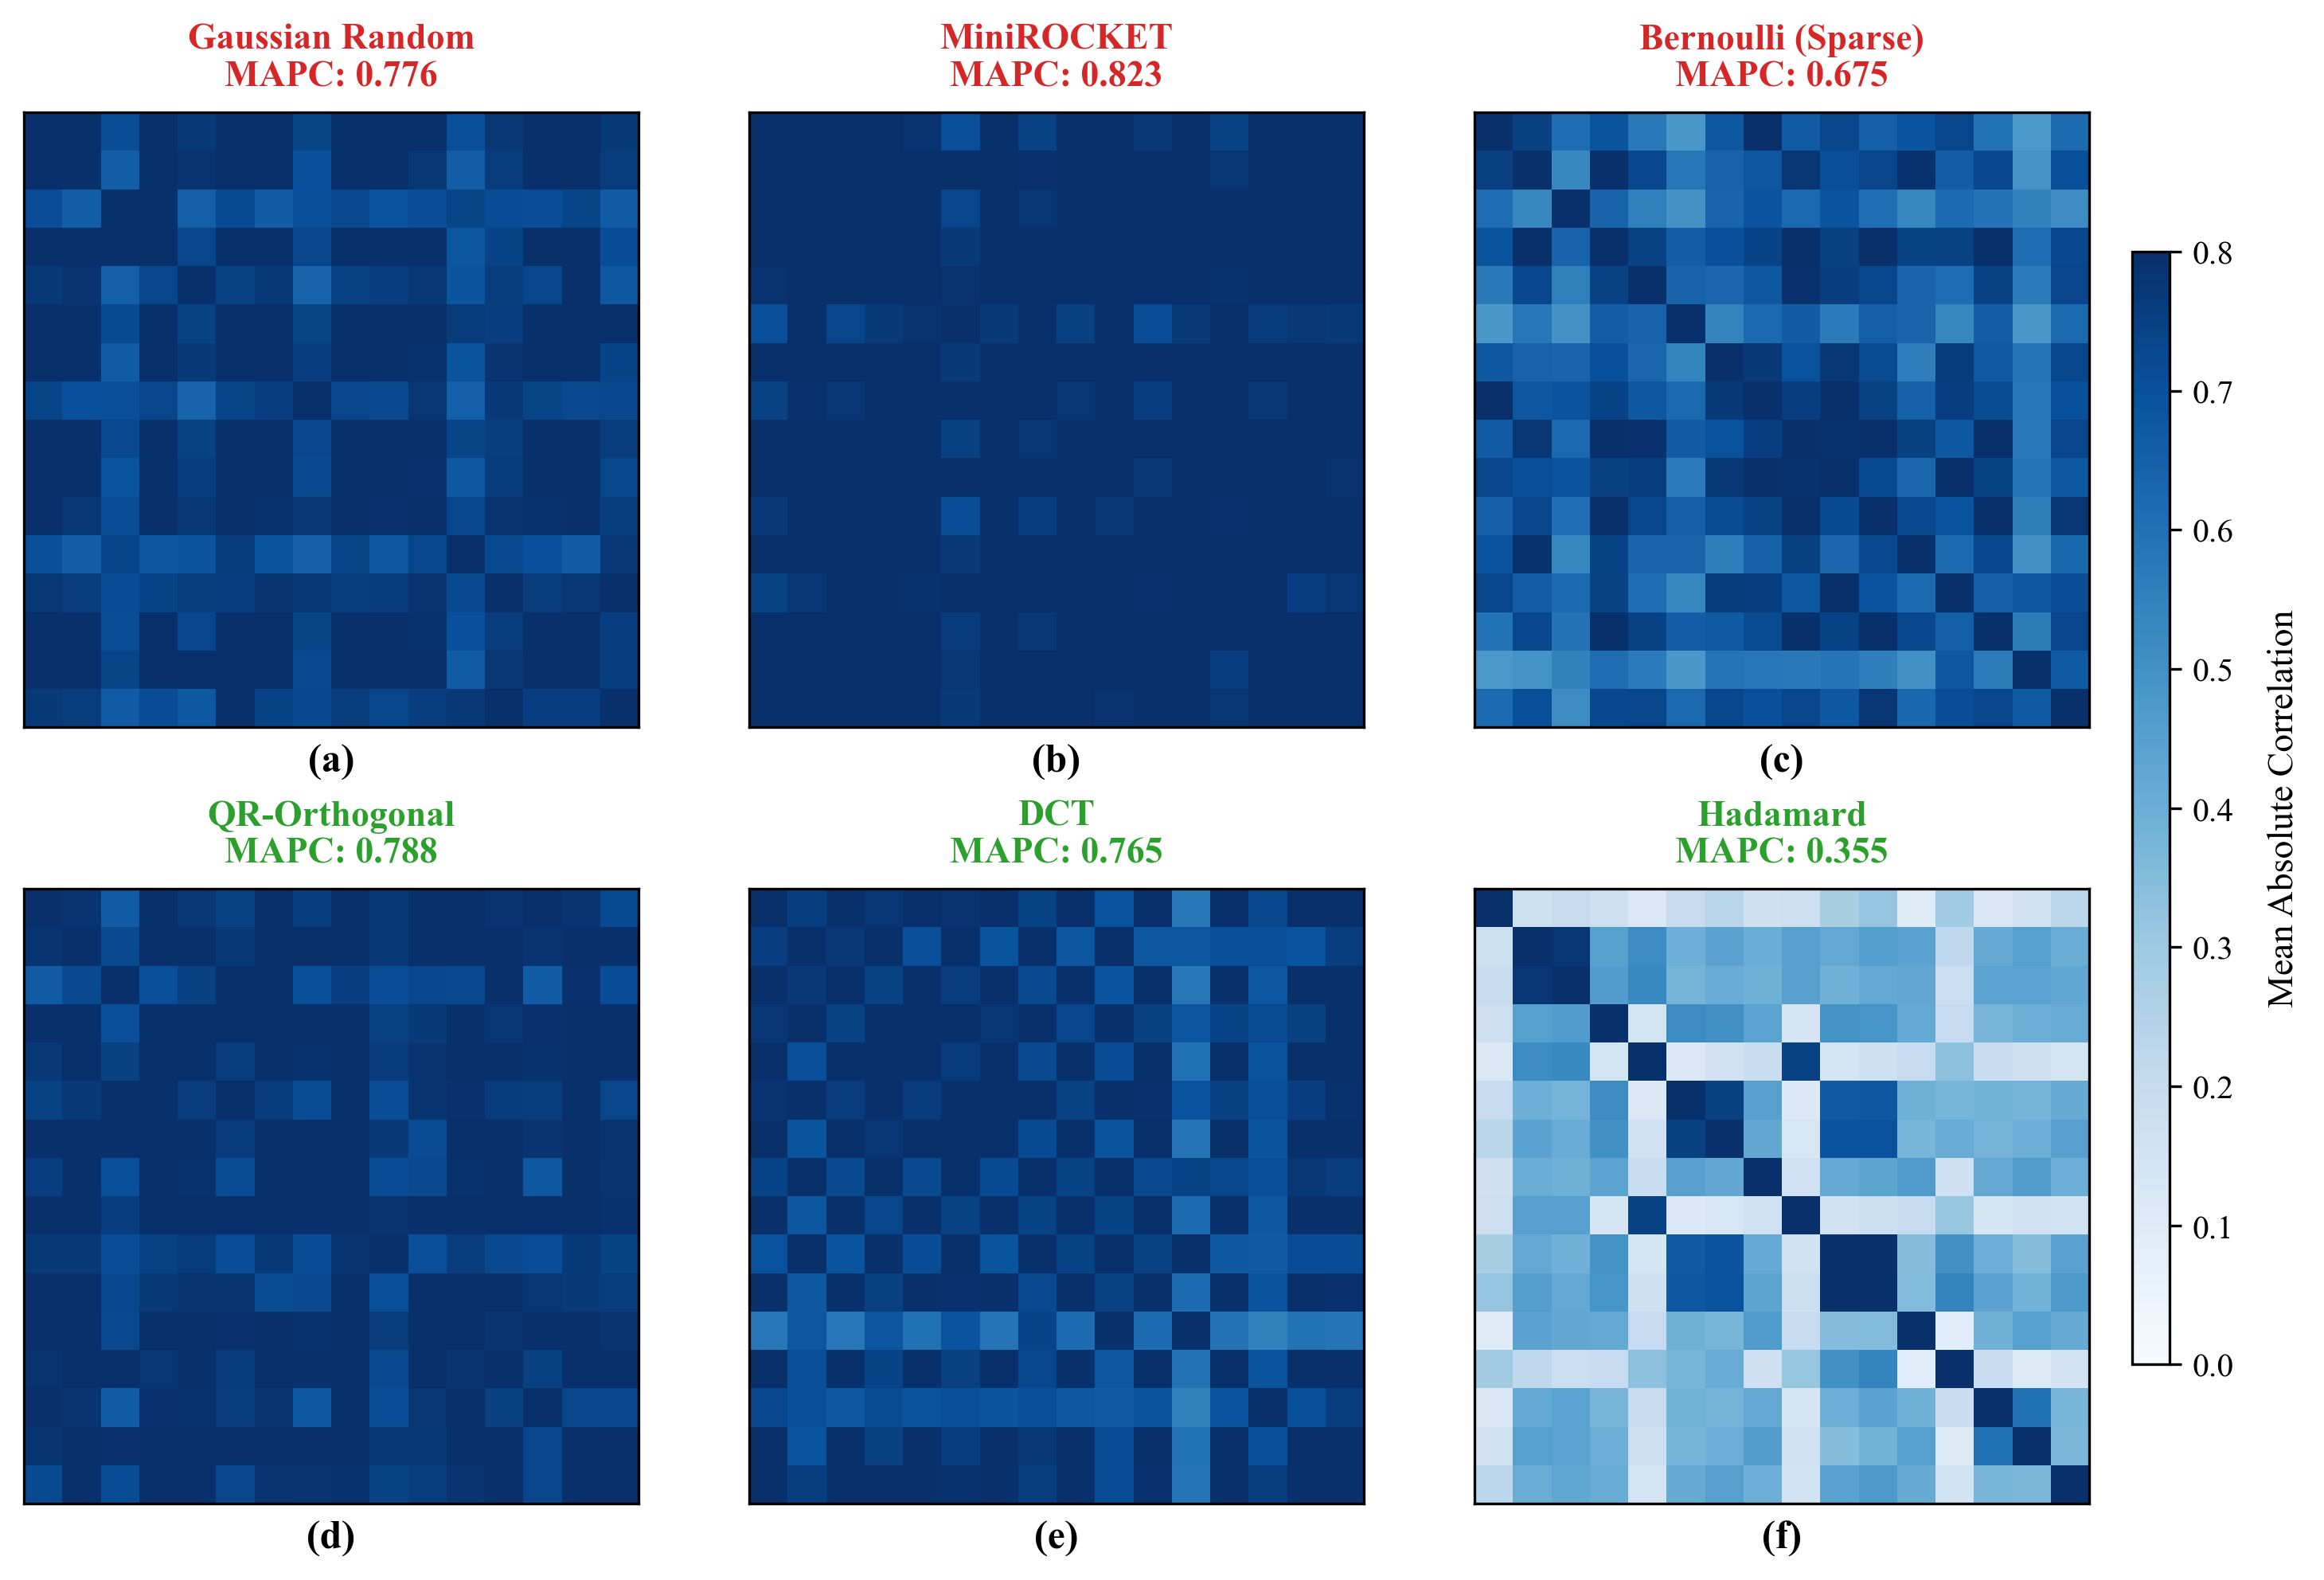

In [8]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.linalg import hadamard
from scipy.fftpack import dct
import warnings

warnings.filterwarnings("ignore")

# ==========================================
# 0. 绘图风格
# ==========================================
def set_journal_style():
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman']
    plt.rcParams['font.size'] = 12

# ==========================================
# 1. 核心转换类
# ==========================================
class KernelComparisonTransform:
    def __init__(self, kernel_len=16, num_kernels=16):
        self.kernel_len = kernel_len
        self.num_kernels = num_kernels

    def generate_kernels(self, method):
        if method == 'Gaussian Random':
            return torch.randn(self.num_kernels, 1, self.kernel_len)
        elif method == 'MiniROCKET':
            kernels = np.random.choice([-1, 2], size=(self.num_kernels, 1, self.kernel_len))
            return torch.FloatTensor(kernels)
        elif method == 'Bernoulli (Sparse)':
            kernels = np.random.choice([-1, 0, 1], size=(self.num_kernels, 1, self.kernel_len))
            return torch.FloatTensor(kernels)
        elif method == 'QR-Orthogonal':
            rand_mat = torch.randn(self.num_kernels, self.kernel_len)
            q, r = torch.linalg.qr(rand_mat)
            return q.unsqueeze(1)
        elif method == 'DCT':
            eye = np.eye(self.kernel_len)
            dct_basis = dct(eye, axis=1, norm='ortho')
            return torch.FloatTensor(dct_basis[:self.num_kernels]).unsqueeze(1)
        elif method == 'Hadamard':
            h_mat = hadamard(self.kernel_len)
            return torch.FloatTensor(h_mat[:self.num_kernels]).unsqueeze(1)
        else:
            raise ValueError(f"Unknown method: {method}")

    def transform(self, X, method):
        X_tensor = torch.FloatTensor(X).unsqueeze(1)
        if torch.cuda.is_available(): X_tensor = X_tensor.cuda()
        weight = self.generate_kernels(method)
        if torch.cuda.is_available(): weight = weight.cuda()
        conv_out = F.conv1d(X_tensor, weight, padding=0)
        ppv = torch.mean((conv_out > 0).float(), dim=2)
        return ppv.cpu().numpy()

# ==========================================
# 2. 数据清洗 (增强版)
# ==========================================
def preprocess_data(X_raw):
    df = pd.DataFrame(X_raw)
    df = df.interpolate(method='linear', axis=1, limit_direction='both')
    row_means = df.mean(axis=1)
    df = df.apply(lambda row: row.fillna(row_means[row.name]), axis=1)
    df = df.fillna(0.0)
    return df.values.astype(np.float32)

# ==========================================
# 3. 主程序
# ==========================================
def main():
    set_journal_style()
    
    # 请务必确认这个路径下真的有文件夹，且文件夹里有 _TRAIN.tsv
    base_folder = r'F:\datasheet\03时间序列分类\02urc\UCRArchive_2018' 
    output_dir = "./05_journal_plots_debug"
    dataset_limit = 10
    
    methods = [
        'Gaussian Random', 'MiniROCKET', 'Bernoulli (Sparse)', 
        'QR-Orthogonal',   'DCT',        'Hadamard'
    ]
    
    os.makedirs(output_dir, exist_ok=True)
    
    # 1. 检查主路径
    if not os.path.exists(base_folder):
        print(f"❌ 严重错误：主路径不存在 -> {base_folder}")
        return

    try:
        subfolders = sorted([f for f in os.listdir(base_folder) if os.path.isdir(os.path.join(base_folder, f))])
    except Exception as e:
        print(f"❌ 读取文件夹列表失败: {e}")
        return

    if len(subfolders) == 0:
        print("❌ 主路径下没有发现子文件夹！请检查路径层级。")
        return

    agg_matrices = {m: np.zeros((16, 16)) for m in methods}
    valid_count = 0
    transformer = KernelComparisonTransform(kernel_len=16, num_kernels=16)

    print(f"🚀 开始调试模式，尝试读取前 {dataset_limit} 个数据集...")

    for idx, subfolder in enumerate(subfolders):
        if valid_count >= dataset_limit: break
            
        train_file = os.path.join(base_folder, subfolder, f"{subfolder}_TRAIN.tsv")
        
        # 调试信息 1
        if not os.path.exists(train_file):
            print(f"⚠️ 跳过 {subfolder}: 文件不存在 -> {train_file}")
            continue
        
        try:
            # 调试信息 2: 尝试读取
            # 使用 sep=None + engine='python' 自动推断分隔符（兼容逗号和Tab）
            df_raw = pd.read_csv(train_file, sep=None, engine='python', header=None)
            X = preprocess_data(df_raw.iloc[:, 1:].values)
            
            # 调试信息 3: 检查维度
            if len(X) < 2:
                print(f"⚠️ 跳过 {subfolder}: 样本数过少 ({len(X)})")
                continue
            if X.shape[1] < 16:
                print(f"⚠️ 跳过 {subfolder}: 序列太短 ({X.shape[1]})")
                continue

            print(f"✅ 成功加载 [{valid_count+1}]: {subfolder} (Shape: {X.shape})")

            for method in methods:
                feats = transformer.transform(X, method)
                std = np.std(feats, axis=0)
                valid_mask = std > 1e-9
                
                corr_curr = np.zeros((16, 16))
                if np.sum(valid_mask) >= 2:
                    feats_valid = feats[:, valid_mask]
                    corr_valid = np.corrcoef(feats_valid, rowvar=False)
                    # 确保没有 NaN
                    corr_valid = np.nan_to_num(corr_valid, nan=0.0)
                    
                    n_v = min(corr_valid.shape[0], 16)
                    corr_curr[:n_v, :n_v] = np.abs(corr_valid)
                
                agg_matrices[method] += corr_curr
            
            valid_count += 1
            
        except Exception as e:
            print(f"❌ 处理 {subfolder} 时出错: {e}")
            continue

    # --- 关键检查 ---
    if valid_count == 0:
        print("\n⛔ 致命错误：没有成功处理任何一个数据集！")
        print("   -> 请检查文件路径结构是否正确 (e.g., folder/DatasetName/DatasetName_TRAIN.tsv)")
        print("   -> 请检查文件内容格式是否损坏")
        return # 提前退出，不画图

    print(f"\n🎨 成功处理了 {valid_count} 个数据集，开始绘图...")
    
    fig, axes = plt.subplots(2, 3, figsize=(10, 6.5), constrained_layout=True)
    axes_flat = axes.flatten()
    labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

    for i, method in enumerate(methods):
        ax = axes_flat[i]
        # 这里之前如果 valid_count=0 就会除以零报错
        avg_matrix = agg_matrices[method] / valid_count
        
        mask = ~np.eye(avg_matrix.shape[0], dtype=bool)
        avg_mapc = avg_matrix[mask].mean()
        
        sns.heatmap(avg_matrix, vmin=0, vmax=0.8, cmap='Blues', 
                    cbar=False, ax=ax, square=True,
                    xticklabels=False, yticklabels=False,
                    linewidths=0.0)
        
        for _, spine in ax.spines.items():
            spine.set_visible(True)
            spine.set_linewidth(0.8)
        
        title_color = '#d62728' if i < 3 else '#2ca02c' 
        ax.set_title(f"{method}\nMAPC: {avg_mapc:.3f}", 
                     fontsize=11, fontweight='bold', color=title_color, pad=8)
        ax.set_xlabel(labels[i], fontsize=12, fontweight='bold', labelpad=5)

    im = axes_flat[0].collections[0]
    cbar = fig.colorbar(im, ax=axes, shrink=0.8, location='right', aspect=30, pad=0.02)
    cbar.set_label('Mean Absolute Correlation', fontsize=11, labelpad=10)
    cbar.outline.set_linewidth(0.8)

    save_path = f"{output_dir}/Journal_Heatmap_Debug.png"
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    
    print(f"✅ 修复完成！图片已保存至: {save_path}")

if __name__ == "__main__":
    main()